# TC2034 Modelación del Aprendizaje con Inteligencia Artificial
## Aprendizaje Supervisado
### Predicción de Éxito de una canción

In [1]:
# importar la biblioteca para análisis de datos
import numpy as np
# importar la biblioteca para graficación
import matplotlib.pyplot as plt
%matplotlib inline
# importar la biblioteca para manipulación y tratamiento de datos
import pandas as pd

## Lectura y preprocesamiento del conjunto de datos

In [2]:
# leer el conjunto de datos a utilizar
# Nota: Reducimos la muestra a 15,000 para que los modelos no lineales (como SVM) 
# puedan compilar en un tiempo razonable.
df = pd.read_csv('../datasets/spotify.csv')

df = df.sample(n=15000, random_state=42).copy()

In [3]:
# desplegar las primeras 5 líneas del dataframe
df.head()

# Categóricos: track_genre, key, explicit, mode.  Ordinales: time_signature.
# Continuos: danceability, energy, speechiness, aousticness, instrumentalness, liveness, valence, loudness, tempo, duration_ms, popularity.
# Alfanumericas: track_id, artists, album_name, track_name.

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
113186,113186,6KwkVtXm8OUp2XffN5k7lY,Hillsong Worship,No Other Name,No Other Name,50,440247,False,0.369,0.598,...,-6.984,1,0.0304,0.00511,0.000000,0.176,0.0466,148.014,4,world-music
42819,42819,2dp5I5MJ8bQQHDoFaNRFtX,Internal Rot,Grieving Birth,Failed Organum,11,93933,False,0.171,0.997,...,-3.586,1,0.1180,0.00521,0.801000,0.420,0.0294,122.223,4,grindcore
59311,59311,5avw06usmFkFrPjX8NxC40,Zhoobin Askarieh;Ali Sasha,Noise A Noise 20.4-1,"Save the Trees, Pt. 1",0,213578,False,0.173,0.803,...,-10.071,0,0.1440,0.61300,0.001910,0.195,0.0887,75.564,3,iranian
91368,91368,75hT0hvlESnDJstem0JgyR,Bryan Adams,All I Want For Christmas Is You,Merry Christmas,0,151387,False,0.683,0.511,...,-5.598,1,0.0279,0.40600,0.000197,0.111,0.5980,109.991,3,rock
61000,61000,4bY2oZGA5Br3pTE1Jd1IfY,Nogizaka46,バレッタ TypeD,月の大きさ,57,236293,False,0.555,0.941,...,-3.294,0,0.0481,0.48400,0.000000,0.266,0.8130,92.487,4,j-idol


In [4]:
# mostrar la información condensada del contenido del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 113186 to 1380
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        15000 non-null  int64  
 1   track_id          15000 non-null  object 
 2   artists           14999 non-null  object 
 3   album_name        14999 non-null  object 
 4   track_name        14999 non-null  object 
 5   popularity        15000 non-null  int64  
 6   duration_ms       15000 non-null  int64  
 7   explicit          15000 non-null  bool   
 8   danceability      15000 non-null  float64
 9   energy            15000 non-null  float64
 10  key               15000 non-null  int64  
 11  loudness          15000 non-null  float64
 12  mode              15000 non-null  int64  
 13  speechiness       15000 non-null  float64
 14  acousticness      15000 non-null  float64
 15  instrumentalness  15000 non-null  float64
 16  liveness          15000 non-null  float64

In [5]:
# determinar la cantidad de datos distintos en cada columna
df.nunique()

Unnamed: 0          15000
track_id            14405
artists              8700
album_name          10801
track_name          13233
popularity             96
duration_ms         11949
explicit                2
danceability          922
energy               1259
key                    12
loudness             8709
mode                    2
speechiness          1227
acousticness         3473
instrumentalness     3731
liveness             1520
valence              1416
tempo               11473
time_signature          5
track_genre           114
dtype: int64

In [6]:
# estadísticas de los atributos numéricos
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,15000.000000,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,56289.289533,33.056933,2.276999e+05,0.564841,0.643134,5.297333,-8.192749,0.634000,0.084892,0.315584,0.152131,0.215586,0.474071,122.344780,3.906267
std,32628.912592,22.271024,1.017910e+05,0.174998,0.251591,3.566236,4.949631,0.481726,0.107005,0.334442,0.305421,0.192254,0.260627,30.231357,0.431771
min,31.000000,0.000000,0.000000e+00,0.000000,0.000020,0.000000,-42.864000,0.000000,0.000000,0.000000,0.000000,0.013700,0.000000,0.000000,0.000000
25%,28416.250000,17.000000,1.737330e+05,0.454000,0.473000,2.000000,-9.969250,0.000000,0.035900,0.016500,0.000000,0.098600,0.254000,99.199250,4.000000
50%,56042.000000,34.000000,2.134325e+05,0.579000,0.685000,5.000000,-6.949500,1.000000,0.048800,0.167500,0.000043,0.133000,0.464000,122.048000,4.000000
75%,84223.000000,50.000000,2.612382e+05,0.694000,0.855000,8.000000,-4.995750,1.000000,0.084900,0.599000,0.044000,0.278000,0.683250,140.882000,4.000000
max,113986.000000,97.000000,4.334721e+06,0.980000,1.000000,11.000000,1.795000,1.000000,0.962000,0.996000,1.000000,1.000000,0.992000,243.372000,5.000000


In [7]:
# estadísticas de los atributos string (Object)
df.describe(include=['O'])

,track_id,artists,album_name,track_name,track_genre
count,15000,14999,14999,14999,15000
unique,14405,8700,10801,13233,114
top,6nvbYcbL79UQ5VFKE0aeeq,George Jones,Feliz Cumpleaños con Perreo,Run Rudolph Run,grindcore
freq,3,44,24,19,159


In [8]:
df.isnull().sum()

Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

# Suposiciones basadas en el análisis de datos
Llegamos a las siguientes suposiciones basados en el análisis de datos realizados hasta ahora. Podríamos validar más estos supuestos antes de tomar las acciones apropiadas.

### Correlacionando

1. Queremos saber qué tan bien se correlacionan características físicas del audio (como `danceability`, `energy`, `loudness`) con la probabilidad de que la canción sea un éxito comercial (`Hit`).


### Completando / Imputando

1. El dataset original de Kaggle contiene un valor nulo en `track_name` y `artists`. Deberemos eliminar esta fila o columna ya que los modelos de Scikit-Learn no toleran nulos.


### Corrigiendo.

1. track_id se debe eliminar de nuestra matriz de características (X), ya que es un identificador alfanumérico único para la base de datos de Spotify y no aporta ninguna varianza matemática para decidir si es un Hit.
2. track_name, album_name y artists se pueden eliminar del análisis lineal, ya que son cadenas de texto libre altamente variables y requerirían técnicas de Procesamiento de Lenguaje Natural (NLP).
3. La columna original popularity debe ser eliminada del conjunto de entrenamiento, ya que se utilizará para definir nuestra variable de salida. Dejarla causaría data leakage, haciendo que el modelo memorice la respuesta en lugar de aprenderla.

### Creando

1. Se creará una nueva característica binaria de clasificación llamada Hit (donde 1 = Sí, 0 = No) basada en la regla de negocio de que cualquier canción con una popularity igual o superior a 75 se considera un éxito comercial.
2. Transformaremos características categóricas nominales y ordinales como track_genre, key (tonalidad) y time_signature (compás) en múltiples columnas binarias de 0 y 1 (One-Hot Encoding) para que los algoritmos puedan procesarlas numéricamente.


### Clasificando

También podemos agregar a nuestras suposiciones, en función del conocimiento empírico de la industria musical contemporánea, que:

1. Las canciones con alta bailabilidad (danceability) y alto nivel de energía (energy) tienen más probabilidades de haber sido clasificadas como Hits.
2. Los géneros orientados al mercado masivo (track_genre = 'pop', 'reggaeton', 'dance') tienen significativamente más probabilidades de alcanzar el estatus de Hit en comparación con géneros de nicho (ej. 'classical', 'grindcore').
3. Las pistas con altos niveles de instrumentalness (ausencia de vocales) o alta acousticness suelen tener probabilidades más bajas de convertirse en un éxito comercial mainstream.

In [9]:
# CREACIÓN DE LA VARIABLE OBJETIVO (Y)
# Convertimos 'popularity' en un problema binario: 1 si es Hit (>= 75), 0 si no.
df['Hit'] = (df['popularity'] >= 75).astype(int)

In [10]:
# Suponiendo que tu variable objetivo (columna) se llama y_train
conteo = df['Hit'].value_counts()
print(conteo)

Hit
0    14656
1      344
Name: count, dtype: int64


In [11]:
df.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,Hit
count,15000.000000,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,56289.289533,33.056933,2.276999e+05,0.564841,0.643134,5.297333,-8.192749,0.634000,0.084892,0.315584,0.152131,0.215586,0.474071,122.344780,3.906267,0.022933
std,32628.912592,22.271024,1.017910e+05,0.174998,0.251591,3.566236,4.949631,0.481726,0.107005,0.334442,0.305421,0.192254,0.260627,30.231357,0.431771,0.149696
min,31.000000,0.000000,0.000000e+00,0.000000,0.000020,0.000000,-42.864000,0.000000,0.000000,0.000000,0.000000,0.013700,0.000000,0.000000,0.000000,0.000000
25%,28416.250000,17.000000,1.737330e+05,0.454000,0.473000,2.000000,-9.969250,0.000000,0.035900,0.016500,0.000000,0.098600,0.254000,99.199250,4.000000,0.000000
50%,56042.000000,34.000000,2.134325e+05,0.579000,0.685000,5.000000,-6.949500,1.000000,0.048800,0.167500,0.000043,0.133000,0.464000,122.048000,4.000000,0.000000
75%,84223.000000,50.000000,2.612382e+05,0.694000,0.855000,8.000000,-4.995750,1.000000,0.084900,0.599000,0.044000,0.278000,0.683250,140.882000,4.000000,0.000000
max,113986.000000,97.000000,4.334721e+06,0.980000,1.000000,11.000000,1.795000,1.000000,0.962000,0.996000,1.000000,1.000000,0.992000,243.372000,5.000000,1.000000


In [12]:
# Por cuestiones de tiempo, para nuestro ejemplo, eliminaremos las columnas PassengerId, Name, Ticket y Cabin
columnas_a_eliminar = ['popularity', 'track_id', 'track_name', 'album_name', 'artists', 'Unnamed: 0']
df2 = df.drop(columns=columnas_a_eliminar)

# mostrar la información condensada del nuevo dataframe
df2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 113186 to 1380
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   duration_ms       15000 non-null  int64  
 1   explicit          15000 non-null  bool   
 2   danceability      15000 non-null  float64
 3   energy            15000 non-null  float64
 4   key               15000 non-null  int64  
 5   loudness          15000 non-null  float64
 6   mode              15000 non-null  int64  
 7   speechiness       15000 non-null  float64
 8   acousticness      15000 non-null  float64
 9   instrumentalness  15000 non-null  float64
 10  liveness          15000 non-null  float64
 11  valence           15000 non-null  float64
 12  tempo             15000 non-null  float64
 13  time_signature    15000 non-null  int64  
 14  track_genre       15000 non-null  object 
 15  Hit               15000 non-null  int64  
dtypes: bool(1), float64(9), int64(5), object(

In [13]:
# Convierte datos string en numéricos introduciendo variables dummy
# para los atributos de sexo y puerto de embarque
df3 = pd.get_dummies(df2,columns=['track_genre', 'key', 'time_signature'], drop_first=True)

# muestra las primeras 5 líneas del dataframe resultante
df3.head()

,duration_ms,explicit,danceability,energy,loudness,mode,speechiness,acousticness,instrumentalness,liveness,...,key_6,key_7,key_8,key_9,key_10,key_11,time_signature_1,time_signature_3,time_signature_4,time_signature_5
113186,440247,False,0.369,0.598,-6.984,1,0.0304,0.00511,0.000000,0.176,...,False,True,False,False,False,False,False,False,True,False
42819,93933,False,0.171,0.997,-3.586,1,0.1180,0.00521,0.801000,0.420,...,False,True,False,False,False,False,False,False,True,False
59311,213578,False,0.173,0.803,-10.071,0,0.1440,0.61300,0.001910,0.195,...,False,False,False,True,False,False,False,True,False,False
91368,151387,False,0.683,0.511,-5.598,1,0.0279,0.40600,0.000197,0.111,...,True,False,False,False,False,False,False,True,False,False
61000,236293,False,0.555,0.941,-3.294,0,0.0481,0.48400,0.000000,0.266,...,False,False,False,True,False,False,False,False,True,False


## Creación de conjuntos de entrenamiento y prueba

In [14]:
# crea los conjuntos de entrenamiento (80%) y prueba (20%)
from sklearn.model_selection import train_test_split

X = df3.drop(columns=['Hit'])
y = df3['Hit']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123, stratify=y)

# muestra la forma de los distintos conjuntos de datos obtenidos
print("Datos de entrenamiento=", X_train.shape, y_train.shape)
print("Datos de prueba=", X_test.shape, y_test.shape)

Datos de entrenamiento= (12000, 140) (12000,)
Datos de prueba= (3000, 140) (3000,)


In [15]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler
dataScaler = RobustScaler()

# Hacemos fit y transform a la vez solo en X_train
X_train_scaled = dataScaler.fit_transform(X_train)

# Transformamos X_test usando lo aprendido de X_train
X_test_scaled = dataScaler.transform(X_test)

X_train = pd.DataFrame(X_train_scaled, columns=X.columns)
X_test = pd.DataFrame(X_test_scaled, columns=X.columns)

print("Datos de entrenamiento=", X_train.shape, y_train.shape)
print("Datos de prueba=", X_test.shape, y_test.shape)

Datos de entrenamiento= (12000, 140) (12000,)
Datos de prueba= (3000, 140) (3000,)


## Creación de Modelos de Aprendizaje

### Regresión Logística

In [17]:
# determina, entre algunas alternativas, los mejores valores de hiperparámetros
# para construir una regresion logística para el problema
from sklearn.model_selection import RandomizedSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
import warnings
warnings.filterwarnings("ignore")

parameters = {
    'C': np.logspace(-4, 4, 50),
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'max_iter': [100, 500, 1000]
}

lrc_rand = RandomizedSearchCV(LogisticRegression(random_state=1, class_weight='balanced'), 
                              param_distributions=parameters, 
                              n_iter=20, cv=5, return_train_score=True, random_state=42, scoring = 'f1_macro', n_jobs=-1)
lrc_rand.fit(X_train, y_train)

print("Mejores hiperparámetros Regresión Logística\n", lrc_rand.best_params_)

Mejores hiperparámetros Regresión Logística
 {'solver': 'lbfgs', 'max_iter': 1000, 'C': np.float64(0.08685113737513521)}


In [18]:
lrc_model = lrc_rand.best_estimator_
print("\nExactitud en prueba:", lrc_model.score(X_test, y_test))


Exactitud en prueba: 0.777


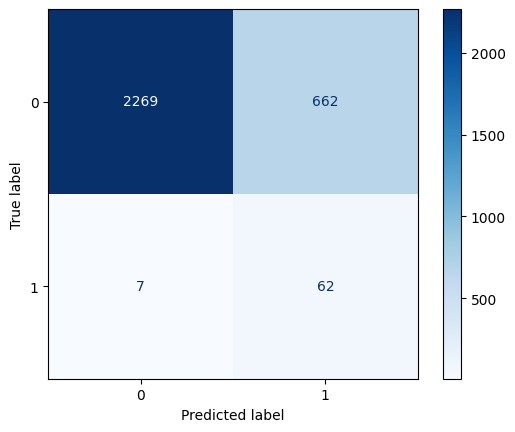

              precision    recall  f1-score   support

           0       1.00      0.77      0.87      2931
           1       0.09      0.90      0.16        69

    accuracy                           0.78      3000
   macro avg       0.54      0.84      0.51      3000
weighted avg       0.98      0.78      0.86      3000



In [19]:
ConfusionMatrixDisplay.from_estimator(lrc_model, X_test, y_test, cmap="Blues")
plt.show()
print(classification_report(y_test, lrc_model.predict(X_test)))

### Bosque Aleatorio (Random Forest)

In [20]:
from sklearn.ensemble import RandomForestClassifier

parameters_rf = {
    'n_estimators': [50, 100, 150],
    'max_depth': [5, 10, None],
    'max_features': ['sqrt', 'log2', None],
    'min_samples_split': [2, 5, 10]
}

rfc_grid = RandomizedSearchCV(RandomForestClassifier(random_state=42, class_weight='balanced'), 
                              param_distributions=parameters_rf, n_iter=10, cv=5, scoring='f1_macro', n_jobs=-1)
rfc_grid.fit(X_train, y_train)

print("Mejores hiperparámetros Random Forest\n", rfc_grid.best_params_)

Mejores hiperparámetros Random Forest
 {'n_estimators': 50, 'min_samples_split': 5, 'max_features': 'sqrt', 'max_depth': 10}


In [21]:
rfc_model = rfc_grid.best_estimator_
print("\nExactitud en prueba:", rfc_model.score(X_test, y_test))


Exactitud en prueba: 0.8283333333333334


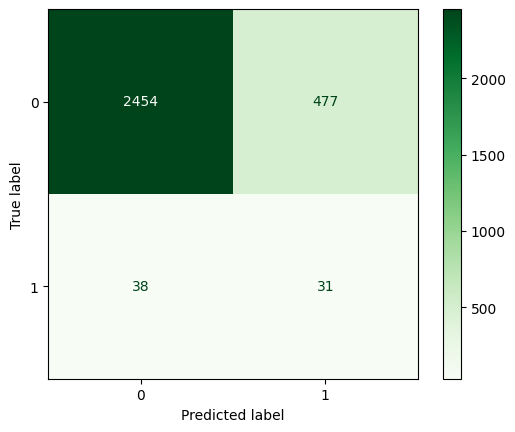

              precision    recall  f1-score   support

           0       0.98      0.84      0.91      2931
           1       0.06      0.45      0.11        69

    accuracy                           0.83      3000
   macro avg       0.52      0.64      0.51      3000
weighted avg       0.96      0.83      0.89      3000



In [22]:
# Matriz y Reporte
ConfusionMatrixDisplay.from_estimator(rfc_model, X_test, y_test, cmap="Greens")
plt.show()
print(classification_report(y_test, rfc_model.predict(X_test)))

### Máquina de Vectores de Soporte

In [29]:
from sklearn.svm import SVC

parameters_svm = {
    'C': [0.1, 1, 10, 50],
    'kernel': ['linear', 'poly', 'rbf', 'sigmoid'],
    'gamma': ['scale', 'auto']uh
}

svmc_grid = RandomizedSearchCV(SVC(random_state=42, class_weight='balanced', probability=True), 
                               param_distributions=parameters_svm, n_iter=5, cv=3, n_jobs = -1, scoring = 'f1_macro')
svmc_grid.fit(X_train, y_train)

print("Mejores hiperparámetros SVM\n", svmc_grid.best_params_)

Mejores hiperparámetros SVM
 {'kernel': 'rbf', 'gamma': 'scale', 'C': 10}


In [30]:
svmc_model = svmc_grid.best_estimator_
print("\nExactitud en prueba:", svmc_model.score(X_test, y_test))


Exactitud en prueba: 0.8096666666666666


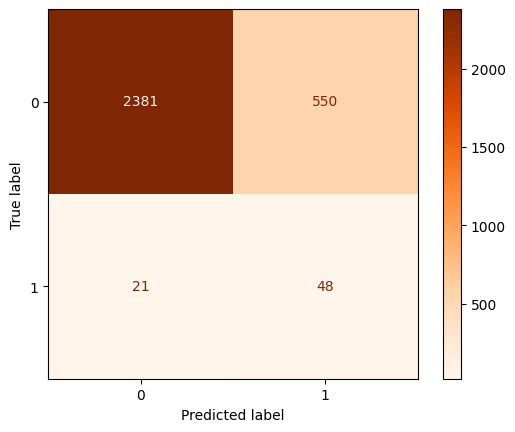

              precision    recall  f1-score   support

           0       0.99      0.81      0.89      2931
           1       0.08      0.70      0.14        69

    accuracy                           0.81      3000
   macro avg       0.54      0.75      0.52      3000
weighted avg       0.97      0.81      0.88      3000



In [31]:
# Matriz y Reporte
ConfusionMatrixDisplay.from_estimator(svmc_model, X_test, y_test, cmap="Oranges")
plt.show()
print(classification_report(y_test, svmc_model.predict(X_test)))

## Mejor Modelo de Aprendizaje mediante Curva ROC

<Figure size 800x600 with 0 Axes>

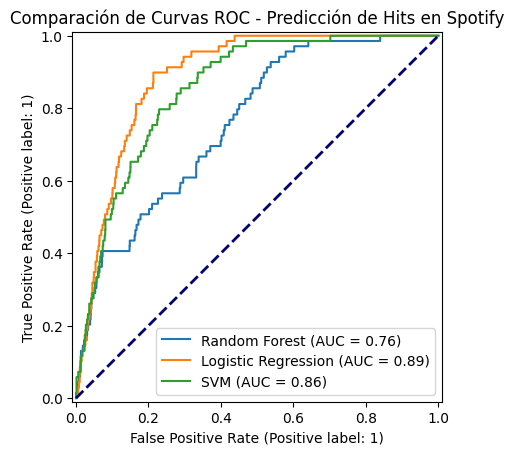

In [32]:
from sklearn.metrics import RocCurveDisplay

plt.figure(figsize=(8,6))
lw = 2

# Obtenemos el "Eje" de la primera gráfica para encimar las demás ahí mismo
disp = RocCurveDisplay.from_estimator(rfc_model, X_test, y_test, name="Random Forest")
RocCurveDisplay.from_estimator(lrc_model, X_test, y_test, ax=disp.ax_, name="Logistic Regression")
RocCurveDisplay.from_estimator(svmc_model, X_test, y_test, ax=disp.ax_, name="SVM")

# Línea de adivinanza aleatoria
plt.plot([0, 1], [0, 1], color="navy", lw=lw, linestyle="--")

plt.title("Comparación de Curvas ROC - Predicción de Hits en Spotify")
plt.legend(loc="lower right")
plt.show()

## **Conclusión**
El modelo de **Regresión Logística** fue el mejor con un AUC de 0.89

# Reflexión

El desarrollo de la actividad de centró en un problema de la industria musical: predecir si una canción se convertirá en un éxito comercial (Hit) basándose en sus propiedades acústicas. Se seleccionaron un conjunto de datos de Spotify representando una complejidad mayor al presentado en clase. Entre las decisiones de ingeniería de datos más importantes, se destaca la eliminación de la columna `popularity` tras generar la variable objetivo binaria; esto con el fin de erradicar la fuga de datos (data leakage). Por otra parte, se convirtieron las variables categóricas de alta cardinalidad como el género y tonalidades con el "One Hot Encoding", usando `drop_first = True` para mitigar la multicolinealidad. Además se reposicionó el Scaler dentro del pipeline, para ubicarlo después del split; con esto garantizando que el modelo se entrene sin conocer la distribución del conjunto de prueba.

Durante la adaptación del código, tuve que modificar datos para la optimización de los recursos computacionales. El primero fue el volumen del dataset original; entrenar una Máquina de Vectores de Soporte (SVM) y un Bosque Aleatorio con validación cruzada sobre más de `11400` registros resultaba computacionalmente ineficiente. La solución fue extraer un muestreo aleatorio representativo de 15,000 observaciones. El segundo cambio fue el desbalanceo extremo de las clases: únicamente el $~2.3%$ de las canciones eran verdaderos Hits. Esto requirió un manejo estadístico cuidadoso, forzando la inclusión del parámetro `stratify=y` en la partición y `class_weight='balanced'` durante la configuración de los hiperparámetros para penalizar fuertemente los errores predictivos en la clase minoritaria.

El análisis de las métricas revela información relevante sobre la mejora de la evaluación de modelos de aprendizaje automático. Al fijarnos en el _accuracy_ el RandomForest parece un mejor modelo, frente a la Regresión Logística y el SVM. Sin embargo, al analizar Sin embargo, al analizar el reporte de clasificación y las curvas ROC, la realidad operativa es muy distinta y demuestra por qué la exactitud es una métrica engañosa en datos desbalanceados.

Para evitar que los modelos simplemente predijeran la clase mayoritaria, configuré la búsqueda de hiperparámetros (RandomizedSearchCV) para optimizar la métrica f1_macro. Esta decisión técnica fue crucial, ya que obligó a los algoritmos a promediar el rendimiento de ambas clases por igual. Al observar los resultados, la Regresión Logística obtuvo la exactitud más baja (78%), pero logró un Recall sobresaliente del 0.90 para la clase 1; esto significa que capturó el 90% de los verdaderos éxitos musicales. En contraste, el Bosque Aleatorio priorizó la exactitud global (83%), pero su Recall se desplomó a 0.45, perdiendo más de la mitad de los Hits reales. El modelo SVM quedó en un punto intermedio con un Recall de 0.70. Finalmente, al evaluar la capacidad de discriminación mediante la Curva ROC, la Regresión Logísticase posicionó como el mejor modelo con un AUC de 0.89. Para este caso de negocio, la Regresión Logística se declara como el modelo ganador por su capacidad superior para no dejar escapar los prospectos de éxito masivo.

Esta actividad consolidó mi comprensión práctica de que, en problemas reales de clasificación, las métricas deben alinearse con el objetivo del negocio. Queda claro que predecir el éxito usando únicamente informacion del audio genera muchos falsos positivos, pues el éxito masivo depende de variables externas (marketing, tendencias, redes sociales) que el audio no captura. Si dispusiera de mayor tiempo, implementaría técnicas de sobremuestreo sintético para equilibrar el conjunto de entrenamiento de raíz, y aplicaría algoritmos de reducción de dimensionalidad (PCA) para comprimir las más de 100 variables binarias que generaron los géneros musicales, buscando incrementar la precisión predictiva sin perder el excelente nivel de detección logrado.